# K-Means Clustering

Ky notebook aplikon **K-Means** mbi te dhenat e shtepive per te identifikuar grupe (segmente) natyrale shtepish me karakteristika te ngjashme.

Per clustering perdorim dataset-in `train_regression_dataset.csv` (i shkallezuar), duke hequr target-in `price`, sepse K-Means eshte nje algoritem **unsupervised** dhe nuk perdor target-in per te mesuar grupimet.

Pas formimit te clusterave, analizojme `price` mesatar per cdo cluster per te kuptuar nese grupimet kane lidhje me cmimin e shtepise.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")

## 1. Leximi i dataset-it

Perdorim `train_regression_dataset.csv` sepse permban target-in numerik `price`, qe na duhet vetem per analize pas clustering-ut, jo per trajnim.

In [2]:
data_dir = Path("../../data/processed")

train_df = pd.read_csv(data_dir / "train_regression_dataset.csv")

print("Train shape:", train_df.shape)
train_df.head()

Train shape: (12810, 53)


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,...,is_luxury_grade,is_high_view,is_premium,waterfront_grade,waterfront_sqft_living,view_grade,view_sqft_living,grade_lat_bin,grade_location_cluster,price
0,-0.400877,-1.474831,-1.014044,-0.225976,-0.905392,-0.073053,-0.297197,-0.637474,-0.552387,-0.736541,...,-0.267931,-0.185695,-0.317936,-0.071886,-0.069208,-0.290494,-0.271083,-0.565504,-0.413012,221900.0
1,-0.400877,0.205526,-0.386572,-0.196899,0.948224,-0.073053,-0.297197,-0.637474,-0.552387,-0.057074,...,-0.267931,-0.185695,-0.317936,-0.071886,-0.069208,-0.290494,-0.271083,-1.675403,-0.265497,257500.0
2,-0.400877,-1.474831,-0.310337,-0.180706,-0.905392,-0.073053,-0.297197,-0.637474,-0.552387,-0.901645,...,-0.267931,-0.185695,-0.317936,-0.071886,-0.069208,-0.290494,-0.271083,-0.565504,-1.150589,229500.0
3,-0.400877,0.541597,1.777328,-0.122849,-0.905392,-0.073053,-0.297197,-0.637474,0.332676,0.127080,...,-0.267931,-0.185695,-0.317936,-0.071886,-0.069208,-0.290494,-0.271083,0.544396,1.905088,662500.0
4,-1.515537,-1.474831,-1.037501,-0.217270,-0.905392,-0.073053,-0.297197,0.886894,-0.552387,-1.142951,...,-0.267931,-0.185695,-0.317936,-0.071886,-0.069208,-0.290494,-0.271083,0.544396,-0.855558,468000.0


## 2. Pergatitja e te dhenave

Heqim kolonen `price` nga veçorite, sepse K-Means perdor vetem `X` per te formuar grupimet. `price` ruhet vec per analize me vone.

In [3]:
target_col = "price"

X = train_df.drop(columns=[target_col])
price = train_df[target_col]

print("Features:", X.shape[1])
print("Samples:", X.shape[0])

Features: 52
Samples: 12810


## 3. Elbow Method

Per te zgjedhur numrin optimal te clusterave (`k`), perdorim Elbow Method, duke vrojtuar inertia (shuma e distancave brenda clusterave) per vlera te ndryshme te `k`.

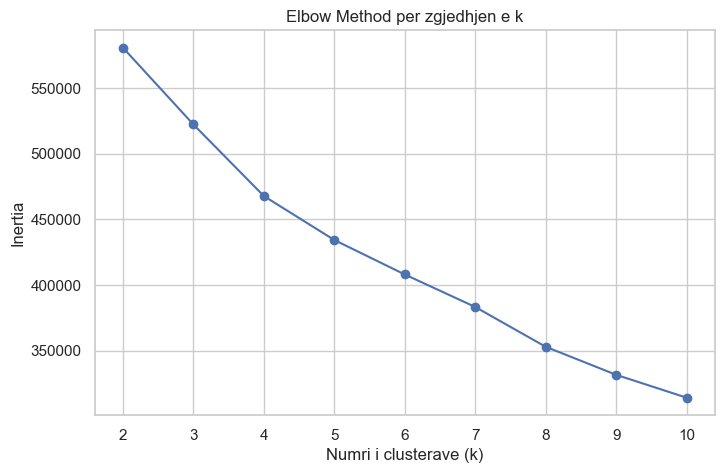

In [4]:
k_values = range(2, 11)
inertia_values = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertia_values, marker="o")
plt.xlabel("Numri i clusterave (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method per zgjedhjen e k")
plt.xticks(list(k_values))
plt.show()

## 4. Silhouette Score

Per te konfirmuar zgjedhjen e `k`, perdorim Silhouette Score, qe mat sa mire ndahen pikat ne clusterat e tyre krahasuar me clusterat e tjere.

k=2: silhouette score = 0.1714
k=3: silhouette score = 0.1478
k=4: silhouette score = 0.1598
k=5: silhouette score = 0.1701
k=6: silhouette score = 0.1412
k=7: silhouette score = 0.1536
k=8: silhouette score = 0.1592
k=9: silhouette score = 0.1725
k=10: silhouette score = 0.1798


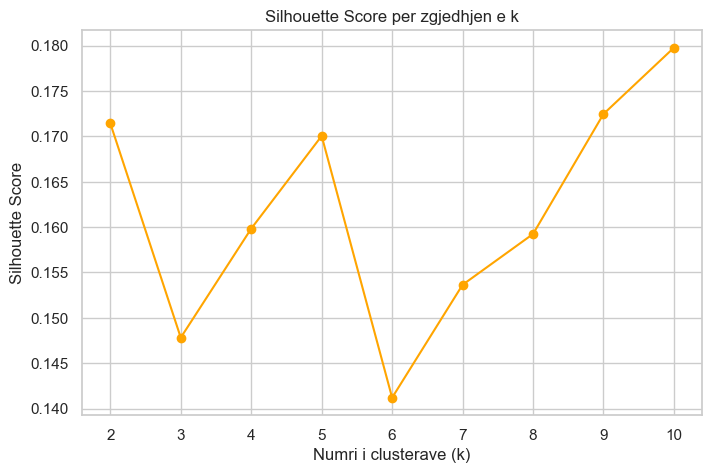

In [5]:
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X)
    score = silhouette_score(X, cluster_labels)
    silhouette_scores.append(score)
    print(f"k={k}: silhouette score = {score:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), silhouette_scores, marker="o", color="orange")
plt.xlabel("Numri i clusterave (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score per zgjedhjen e k")
plt.xticks(list(k_values))
plt.show()

## 5. Modeli final K-Means

Bazuar ne Elbow Method dhe Silhouette Score, zgjedhim numrin final te clusterave dhe trajnojme modelin K-Means.

In [7]:
best_k = 4

final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(X)

X_clustered = X.copy()
X_clustered["cluster"] = cluster_labels
X_clustered["price"] = price.values

print("Numri i shtepive per cluster:")
print(X_clustered["cluster"].value_counts().sort_index())

Numri i shtepive per cluster:
cluster
0    3327
1    2854
2    6561
3      68
Name: count, dtype: int64


## 6. Vizualizimi i clusterave (PCA)

Meqenese kemi shume veçori, perdorim PCA per te reduktuar te dhenat ne 2 dimensione vetem per qellime vizualizimi.

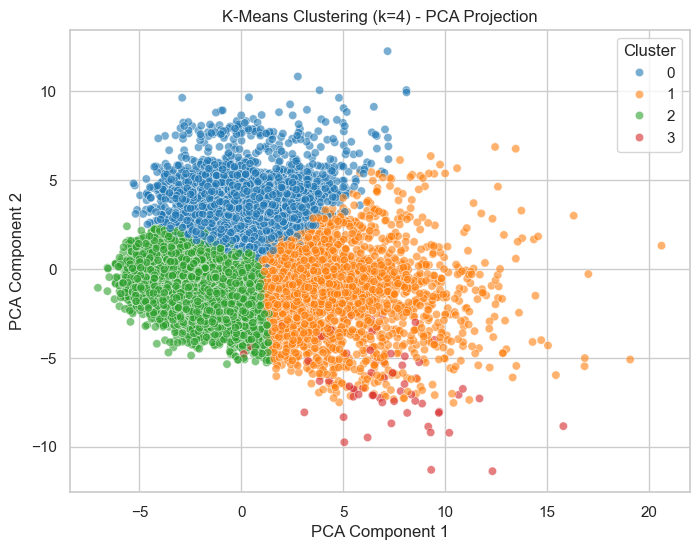

Variance e shpjeguar nga 2 komponentet: 0.343


In [8]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=cluster_labels,
    palette="tab10",
    alpha=0.6
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title(f"K-Means Clustering (k={best_k}) - PCA Projection")
plt.legend(title="Cluster")
plt.show()

print("Variance e shpjeguar nga 2 komponentet:", pca.explained_variance_ratio_.sum().round(3))

## 7. Analiza e clusterave kundrejt cmimit

Krahasojme cmimin mesatar dhe disa veçori kryesore per cdo cluster, per te kuptuar profilin e secilit grup shtepish.


In [9]:
cluster_summary = X_clustered.groupby("cluster").agg(
    count=("price", "size"),
    avg_price=("price", "mean"),
    avg_sqft_living=("sqft_living", "mean"),
    avg_bedrooms=("bedrooms", "mean"),
    avg_bathrooms=("bathrooms", "mean"),
    avg_grade=("grade", "mean"),
).round(2)

cluster_summary

,count,avg_price,avg_sqft_living,avg_bedrooms,avg_bathrooms,avg_grade
cluster,,,,,,
0,3327,330313.32,-0.16,0.02,-0.03,-0.24
1,2854,841546.60,1.31,0.63,0.96,1.22
2,6561,465715.39,-0.49,-0.28,-0.40,-0.41
3,68,1042889.71,0.39,-0.40,0.14,0.38


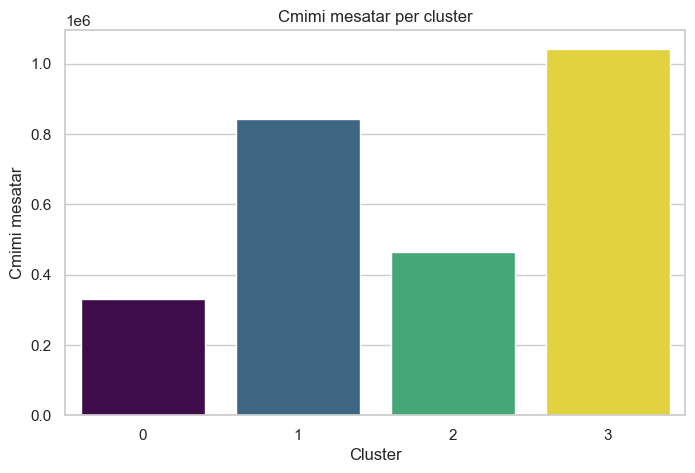

In [11]:
plt.figure(figsize=(8, 5))
sns.barplot(
    x=cluster_summary.index,
    y=cluster_summary["avg_price"],
    hue=cluster_summary.index,
    palette="viridis",
    legend=False
)

plt.xlabel("Cluster")
plt.ylabel("Cmimi mesatar")
plt.title("Cmimi mesatar per cluster")
plt.show()


## 8. Ruajtja e rezultateve

Ruajme cluster labels dhe modelin per perdorim te metejshem.


In [12]:
results_dir = data_dir / "model_results"
results_dir.mkdir(parents=True, exist_ok=True)

cluster_summary.to_csv(results_dir / "kmeans_cluster_summary.csv")

print("Rezultatet u ruajten ne:", results_dir)


Rezultatet u ruajten ne: ..\..\data\processed\model_results
